<a href="https://colab.research.google.com/github/droyktton/ICNPG/blob/master/Clases/Clases_rapids/Clases_cugraph/ICNPG_ejemplocugraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparación: RAPIDS AI y visualizadores

In [ ]:
!nvidia-smi

Wed Mar  4 13:26:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [1]:
#@title Instalación de RapidsAI
# This get the RAPIDS-Colab install files and test check your GPU.  Run this and the next cell only.
# Please read the output of this cell.  If your Colab Instance is not RAPIDS compatible, it will warn you and give you remediation steps.
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/pip-install.py


Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 634 (delta 152), reused 90 (delta 88), pack-reused 434 (from 3)
Receiving objects: 100% (634/634), 209.09 KiB | 8.71 MiB/s, done.
Resolving deltas: 100% (326/326), done.
Installing RAPIDS remaining 26.02 libraries
Using Python 3.12.13 environment at: /usr
Resolved 176 packages in 2.09s
Prepared 10 packages in 2.13s
Uninstalled 4 packages in 535ms
Installed 10 packages in 288ms
 - bokeh==3.8.2
 + bokeh==3.6.3
 + cugraph-cu12==26.2.0
 + cuxfilter-cu12==26.2.0
 + datashader==0.19.0
 - holoviews==1.22.1
 + holoviews==1.20.2
 + jupyter-server-proxy==4.5.0
 - panel==1.8.10
 + panel==1.7.5
 + pyct==0.6.0
 - shapely==2.1.2
 + shapely==2.0.7
 + simpervisor==1.0.0

        ***********************************************************************
        The pip install of RAPIDS is complete.

        Please do 

In [2]:
#@title Este nos viene bien para visualizar grafos
!pip install graphviz
!pip install pyvis


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 124.0 MB/s eta 0:00:00


# CUDF como pandas, pero en GPU

In [3]:
import cudf
import io, requests

# download CSV file from GitHub
url="https://github.com/plotly/datasets/raw/master/tips.csv"
content = requests.get(url).content.decode('utf-8')

# read CSV from memory
tips_df = cudf.read_csv(io.StringIO(content))
tips_df['tip_percentage'] = tips_df['tip']/tips_df['total_bill']*100

# display average tip by dining party size
print(tips_df.groupby('size').tip_percentage.mean())

size
4    14.594901
3    15.215685
2    16.571919
5    14.149549
1    21.729202
6    15.622920
Name: tip_percentage, dtype: float64


# CUGRAPH

Este es un ejemplito de como leer un csv con los edges de un grafo, visualizarlo, y realizar operaciones en la gpu.

## Visualización del grafo y de la matriz de adyacencia

matriz de adjacencia:
 [[1. 1. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 1. 1. 0. 0. 0.]
 [1. 1. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
matriz de adjacencia a la 3:
 [[7. 6. 3. 3. 6. 1. 0. 0. 0.]
 [6. 3. 5. 1. 7. 2. 0. 0. 0.]
 [3. 5. 0. 5. 1. 0. 0. 0. 0.]
 [3. 1. 5. 0. 6. 3. 0. 0. 0.]
 [6. 7. 1. 6. 3. 0. 0. 0. 0.]
 [1. 2. 0. 3. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]]
no zeros de la matriz:  18
no zeros de la matriz^3:  32
traza(G^3) =  14.0


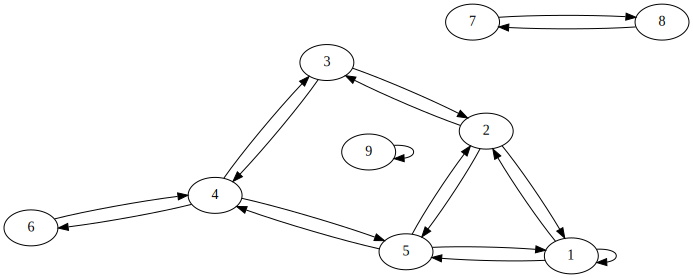

In [4]:
#########################################
# Echemosle un vistazo al grafo usando graphiz

import cugraph
import cudf
import cupy as cp
from graphviz import Digraph

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv")
dot = Digraph(comment='ICNPG2023',engine='sfdp')

gpa=gdf.to_pandas()

madj=cp.zeros((9,9))

for a, b in gpa.itertuples(index=False):
    dot.edge(str(a),str(b), constraint='false')
    madj[a-1,b-1]=1
    #print(a, b)


print("matriz de adjacencia:\n",madj)

madj3=cp.linalg.matrix_power(madj,3)
print("matriz de adjacencia a la 3:\n",madj3)

print("no zeros de la matriz: ",cp.flatnonzero(madj).size)
print("no zeros de la matriz^3: ",cp.flatnonzero(madj3).size)

print("traza(G^3) = ", cp.trace(madj3))

dot

##  CUGRAPH para obtener propiedades del grafo

In [5]:
import cugraph
import cudf

# read data into a cuDF DataFrame using read_csv
#gdf = cudf.read_csv("graph_data.csv", names=["src", "dst"], dtype=["int32", "int32"])
gdf = cudf.read_csv("https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv")

# pesos (necesarios para algunas cosas nomas)
gdf["data"] = 1.0


# We now have data as edge pairs
# create a Graph using the source (src) and destination (dst) vertex pairs
G = cugraph.Graph()
G.from_cudf_edgelist(gdf, source='src', destination='dst', store_transposed=True)

print("\n\n")



######################################
#https://es.wikipedia.org/wiki/PageRank
#
# PR(A) = (1-d)+d Sum_{i=1}^n PR(i)/C(i)
#
# A es el PageRank de la página A.
# d es un factor de amortiguación que tiene un valor entre 0 y 1.
# PR(i)son los valores de PageRank que tienen cada una de las páginas i que enlazan a A.
# C(i) es el número total de enlaces salientes de la página i (sean o no hacia A).

# Let's now get the PageRank score of each vertex by calling cugraph.pagerank
df_page = cugraph.pagerank(G)

# Let's look at the PageRank Score (only do this on small graphs)
for i in range(len(df_page)):
	print("vertex " + str(df_page['vertex'].iloc[i]) +
		" PageRank is " + str(df_page['pagerank'].iloc[i]))

print("\n\n")

#####################################
#https://en.wikipedia.org/wiki/Component_(graph_theory)

# Call cugraph.weakly_connected_components on the dataframe
df_cc = cugraph.weakly_connected_components(G)

# Use groupby on the 'labels' column of the WCC output to get the counts of each connected component label
label_gby = df_cc.groupby('labels')
label_count = label_gby.count()

print("Total number of components found : ", len(label_count))

# Call nlargest on the groupby result to get the row where the component count is the largest
largest_component = label_count.nlargest(n = 1, columns = 'vertex')
print("Size of the largest component is found to be : ", largest_component['vertex'].iloc[0])

smallest_component = label_count.nsmallest(n = 1, columns = 'vertex')
print("Size of the smallest component is found to be : ", smallest_component['vertex'].iloc[0])

#df_cc.head(20)

print("\n\n")

#############################################################
# https://en.wikipedia.org/wiki/Shortest_path_problem
# Call cugraph.sssp to get the distances from vertex 1:

df_ssp = cugraph.bfs(G, 1)

print("no todos los caminos conducen al nodo 1, y estos son los minimos:")

# Print the paths
for index, row in df_ssp.to_pandas().iterrows():
    v = int(row['vertex'])
    p = cugraph.utils.get_traversed_path_list(df_ssp, v)
    print(v, ': ', p)

print("\n\n")





vertex 1 PageRank is 0.12384827
vertex 2 PageRank is 0.12706584
vertex 4 PageRank is 0.13981377
vertex 5 PageRank is 0.12737396
vertex 3 PageRank is 0.09228361
vertex 6 PageRank is 0.05628124
vertex 7 PageRank is 0.11111111
vertex 8 PageRank is 0.11111111
vertex 9 PageRank is 0.11111111



Total number of components found :  3
Size of the largest component is found to be :  6
Size of the smallest component is found to be :  1



no todos los caminos conducen al nodo 1, y estos son los minimos:
1 :  [1]
2 :  [2, np.int64(1)]
4 :  [4, np.int64(5), np.int64(1)]
5 :  [5, np.int64(1)]
3 :  [3, np.int64(2), np.int64(1)]
6 :  [6, np.int64(4), np.int64(5), np.int64(1)]
7 :  [7]
8 :  [8]
9 :  [9]





# NetworkX

Esta es una librería mucho más completa que cuGraph pero para CPU.
Se usa en forma parecida a cuGraph (¡comparar!).


In [6]:
# prompt: I have a graph edge csv file. The file is here https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv .The first column is the source "src" and the second the destination "dst". Read it and build a networkX graph.

import pandas as pd
import networkx as nx

# Read the CSV file into a pandas DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv")

# Create a NetworkX graph from the DataFrame
G = nx.from_pandas_edgelist(df, source='src', target='dst')

# Now you have a NetworkX graph 'G' built from the CSV data

d = nx.coloring.greedy_color(G, strategy="largest_first")

print(d)


{1: 0, 2: 1, 5: 2, 4: 0, 3: 2, 9: 0, 8: 0, 7: 1, 6: 1}


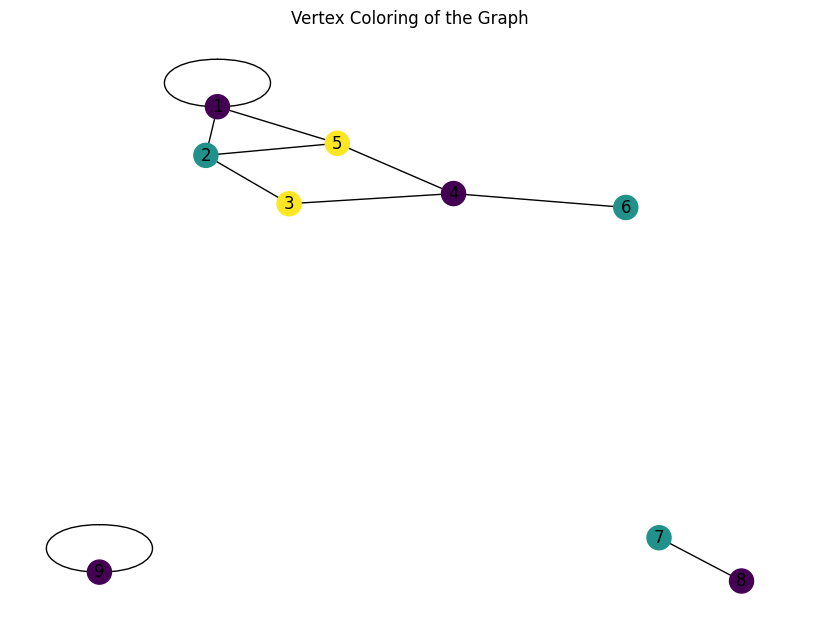

In [7]:
# prompt: I have a graph edge csv file. The file is here https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv .The first column is the source "src" and the second the destination "dst". Read it and build a networkX graph. Then solve the vertex coloring problem, and plot the graph indicating the color of each node

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Read the CSV file into a pandas DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/droyktton/data/main/graph_data.csv")

# Create a NetworkX graph from the DataFrame
G = nx.from_pandas_edgelist(df, source='src', target='dst')

# Solve the vertex coloring problem
d = nx.coloring.greedy_color(G, strategy="largest_first")

# Plot the graph with colored nodes
pos = nx.spring_layout(G)  # Layout for visualization
plt.figure(figsize=(8, 6))
nx.draw(G, pos, node_color=[d[node] for node in G.nodes()], with_labels=True, cmap=plt.cm.viridis)
plt.title("Vertex Coloring of the Graph")
plt.show()


# Experimentación con datos reales

In [8]:
import cudf
import cugraph
import networkx as nx
import plotly.graph_objects as go

# Aqui hay muchas para probar
# https://snap.stanford.edu/data/index.html

# Read the dataset into cuGraph, explicitly setting dtype to string
df = cudf.read_csv("https://snap.stanford.edu/data/ca-CondMat.txt.gz",
                   compression="gzip", skiprows=4, delimiter="\t", header=None,
                   names=["src", "dst"],
                   dtype=['str', 'str'])  # Specify dtype as string

print(df.head())

##################################

# Create cuGraph Graph (GPU-based), allowing renumbering
G_gpu = cugraph.Graph()
G_gpu.from_cudf_edgelist(df, source="src", destination="dst", renumber=True) # Enable renumbering




     src    dst
0  81626  11894
1  81626  16246
2  81626  16322
3  81626  18914
4  81626  19729


In [9]:
#@title Algunas propiedades

import cudf
import cugraph
import numpy as np

# Example: loading a graph from an edge list (modify as per your graph)
# G_gpu = cugraph.load_graph('path_to_your_graph_file')

# 1. Number of nodes
print(f"Number of nodes: {G_gpu.number_of_nodes()}")

# 2. Number of edges
print(f"Number of edges: {G_gpu.number_of_edges()}")

# 3. Nodes
print(f"Nodes: {G_gpu.nodes().to_arrow().to_pylist()}")  # Use to_arrow().to_pylist() instead of to_list()

# 4. Edges (node pairs)
print(f"Edges: {list(G_gpu.edges())}")

# 5. Degree of each node
print("Degree of each node:")
# Get the degree DataFrame
degree_df = G_gpu.degree()

# Iterate through the DataFrame rows
#for index in range(len(degree_df)):
random_numbers = np.random.randint(0, len(degree_df), 20)
for index in random_numbers:
    node = degree_df['vertex'].iloc[index]
    degree = degree_df['degree'].iloc[index]
    print(f"Node {node} has degree {degree}")

# 6. Node attributes (if any)
# Uncomment and use if your nodes have attributes
# print(f"Node attributes: {G_gpu.nodes.data()}")

# 7. Edge attributes (if any)
# Uncomment and use if your edges have attributes
# print(f"Edge attributes: {G_gpu.edges.data()}")

# 8. Check if the graph is directed or undirected
print(f"Is the graph directed? {G_gpu.is_directed()}")

# 9. Graph structure (basic repr)
print(f"Graph structure: {G_gpu.__repr__()}")

# 10. Connected components
connected_components = cugraph.connected_components(G_gpu)
print("Connected components:")
print(connected_components)

# Get the total number of connected components
# Access the 'vertex' column for component labels
num_connected_components = connected_components['vertex'].nunique()
print(f"Total number of connected components: {num_connected_components}")

# 11. Connected component sizes
print("\nConnected component sizes:")
# Group by 'vertex' (component labels) and get the size of each group
component_sizes = connected_components.groupby('vertex').size()

# Rename the index to 'component' for the Series
component_sizes = component_sizes.rename('component')
print(component_sizes)


# Sort the degree DataFrame to find the node with the highest and lowest degree
sorted_degree_df = degree_df.sort_values(by='degree', ascending=False)

# Node with the highest degree (first in the sorted DataFrame)
max_degree_node = sorted_degree_df['vertex'].iloc[0]
max_degree_value = sorted_degree_df['degree'].iloc[0]

# Node with the lowest degree (last in the sorted DataFrame)
min_degree_node = sorted_degree_df['vertex'].iloc[-1]
min_degree_value = sorted_degree_df['degree'].iloc[-1]

print(f"Node with highest degree: {max_degree_node} (Degree: {max_degree_value})")
print(f"Node with lowest degree: {min_degree_node} (Degree: {min_degree_value})")

Number of nodes: 23133
Number of edges: 93497
Nodes: ['1', '100000', '100002', '100005', '100007', '100008', '100009', '10001', '100010', '100020', '10003', '100030', '100032', '100038', '100048', '100050', '100054', '100057', '10006', '100060', '100062', '100074', '100077', '100079', '100081', '100082', '100084', '100086', '100087', '100089', '100094', '100095', '100103', '100108', '100109', '100111', '100113', '100114', '100115', '100120', '100122', '100124', '100127', '100136', '100137', '100138', '100145', '100150', '100151', '100165', '100166', '100171', '10019', '100206', '10021', '10022', '100245', '100247', '100248', '10025', '100250', '100251', '100252', '100254', '10026', '100283', '100284', '100293', '100295', '100296', '100327', '100331', '100334', '100339', '10034', '100342', '100343', '100348', '100349', '100350', '100359', '100361', '100364', '10039', '10040', '100439', '100440', '100441', '100442', '100444', '100446', '100448', '100449', '10045', '100454', '100455', '10

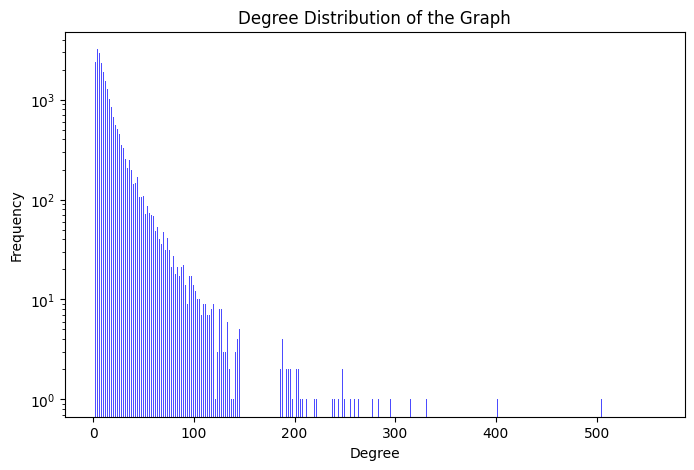

In [10]:
#@title Degree distribution
import cudf
import cugraph
import cupy as cp
import matplotlib.pyplot as plt

# Compute the degree of each node
degree_df = G_gpu.degree()

# Get degree values as a CuPy array
degree_values = degree_df["degree"].to_cupy()

# Compute histogram (degree distribution)
max_degree = int(degree_values.max())
hist, bins = cp.histogram(degree_values, bins=max_degree+1, range=(0, max_degree))

# Convert to NumPy for plotting
hist_np = hist.get()
bins_np = bins.get()

# Plot the degree distribution
plt.figure(figsize=(8, 5))
plt.bar(bins_np[:-1], hist_np, width=0.8, color='b', alpha=0.7)
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution of the Graph")
plt.yscale("log")  # Log scale for better visibility
plt.show()


Unas redes muy interesantes son las del tipo [Small World](https://en.wikipedia.org/wiki/Small-world_network). Un ejemplo son
[Los seis grados de separación](https://en.wikipedia.org/wiki/Six_degrees_of_separation) de las redes sociales. Por ejemplo la red de colaboración de actores de Hollywood y la conexión con los
[grados de separación de Kevin Bacon](https://en.wikipedia.org/wiki/Six_Degrees_of_Kevin_Bacon) y al [Erdos Number](https://en.wikipedia.org/wiki/Erd%C5%91s_number) que mide la conexión con el famoso matemático (si trabaste con el tu número es 1, si trabajaste con alguien que trabajo con él, tu número es 2, etc).


¿Cuál es tu grado de separación con Einstein? ¡Estimalo!


In [11]:
#@title visualizacion plotly
import plotly.graph_objects as go

# Convert the cuGraph graph to NetworkX
pdf_edges = G_gpu.view_edge_list().to_pandas()
G_nx = nx.from_pandas_edgelist(pdf_edges, source="src", target="dst")

# Subsampled version of the graph (1000 nodes)
subsampled_nodes = list(G_nx.nodes)[:500]
subsampled_edges = [(u, v) for u, v in G_nx.edges if u in subsampled_nodes and v in subsampled_nodes]

# Create a subgraph
G_subsampled = nx.Graph()
G_subsampled.add_edges_from(subsampled_edges)

# Position nodes using a spring layout
pos = nx.spring_layout(G_subsampled, k=0.1, iterations=50)

# Extract x and y coordinates for nodes
x_coords = [pos[node][0] for node in G_subsampled.nodes]
y_coords = [pos[node][1] for node in G_subsampled.nodes]

# Create Plotly scatter plot for nodes
node_trace = go.Scatter(x=x_coords, y=y_coords,
                       mode='markers', marker=dict(size=6, color='skyblue', line_width=0.5))

# Create Plotly scatter plot for edges
edge_trace = go.Scatter(x=[], y=[], mode='lines', line=dict(width=0.5, color='gray'))

# Add edges to edge_trace
for edge in G_subsampled.edges:
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_trace['x'] += (x0, x1, None)
    edge_trace['y'] += (y0, y1, None)

# Create the figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(title="Subsampled Graph Visualization", showlegend=False,
                                 hovermode='closest', height=800, width=1000))

# Show the plot
fig.show()


In [12]:
#@title Visualizacion html
import cugraph
import cudf
import networkx as nx
from pyvis.network import Network
import locale

locale.getpreferredencoding = lambda: "UTF-8"

# Subsampled version of the graph (1000 nodes)
subsampled_nodes = list(G_nx.nodes)[:100]
subsampled_edges = [(u, v) for u, v in G_nx.edges if u in subsampled_nodes and v in subsampled_nodes]

# Create a subgraph
G_subsampled = nx.Graph()
G_subsampled.add_edges_from(subsampled_edges)

# Create Pyvis Network
net = Network(notebook=True, cdn_resources='remote')
net.from_nx(G_subsampled)

# ✅ Save and Display the Graph
net.save_graph("graph.html")
#display(HTML("graph.html"))  # ✅ Works inside Colab

from google.colab import files
files.download("graph.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title si sale un error sobre UTF, probablemente se arregle corriendo esto
import locale
def getpreferredencoding(do_setlocale = True):
    return "UTF-8"
locale.getpreferredencoding = getpreferredencoding